# Predicting Heart Disease using Machine Learning

### 1 problem Def
### 2 Data
### 3 Evaluatoin 
### 4 features
### 5 modelling
### 6 experimentation

## problem 
Given Clinical parameters about a patinet , can we predict  whether  or not  have a heart disease

## Data 
This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

Kaggel 
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## Evaluation
>if we can reach 95 acc and predict , we'll pursue the project 


## Features
* age
* sex 1 -> male & 0 -> female
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
* The names and social security numbers of the patients were recently removed
* from the database, replaced with dummy values.

In [3]:
# import the tools 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# import models 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

In [4]:
# load the data
df = pd.read_csv(r"heart-disease.csv")
df.shape

(303, 14)

In [5]:
#explore the data
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df["target"].value_counts()#how many classes are there?

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

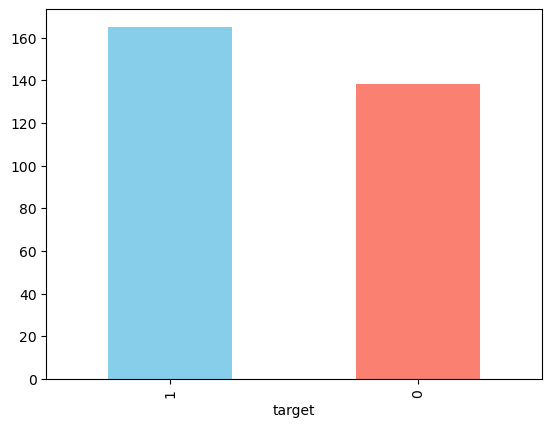

In [7]:
df["target"].value_counts().plot(kind="bar",color=["skyblue","salmon"])


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
# missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
#compare the features to find more patterns


# freq according to sex

df.sex.value_counts()


sex
1    207
0     96
Name: count, dtype: int64

In [12]:
# compare the target with sex
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


In [13]:
# Calculate the percentage of females and males with heart disease
disease_by_sex = pd.crosstab(df.sex, df.target, normalize='index') * 100
print("Percentage of heart disease by sex (0=Female, 1=Male):")
print(disease_by_sex)
print("\nFemales with heart disease:", disease_by_sex.loc[0, 1], "%")
print("Males with heart disease:", disease_by_sex.loc[1, 1], "%")

Percentage of heart disease by sex (0=Female, 1=Male):
target          0          1
sex                         
0       25.000000  75.000000
1       55.072464  44.927536

Females with heart disease: 75.0 %
Males with heart disease: 44.927536231884055 %


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

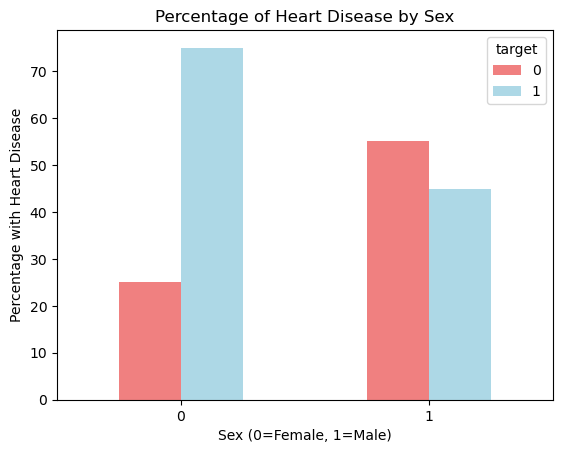

In [14]:
disease_by_sex.plot(kind="bar", color=["lightcoral", "lightblue"])
plt.title("Percentage of Heart Disease by Sex")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.ylabel("Percentage with Heart Disease")
plt.xticks(rotation=0)

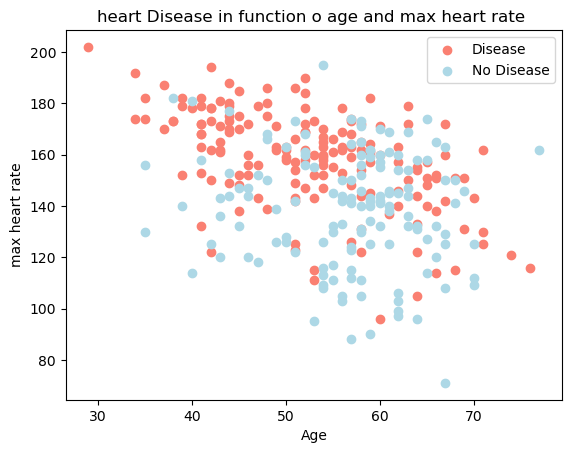

In [19]:
# Scatter with positive examples (target == 1)
# X = age, Y = thalach (max heart rate)
plt.scatter(df.age[df.target==1], 
            df.thalach[df.target==1], 
            c="salmon")

plt.scatter(df.age[df.target==0], 
            df.thalach[df.target==0], 
            c="lightblue")

plt.title("heart Disease in function o age and max heart rate ")
plt.xlabel("Age")
plt.ylabel("max heart rate")
plt.legend(["Disease","No Disease"]);


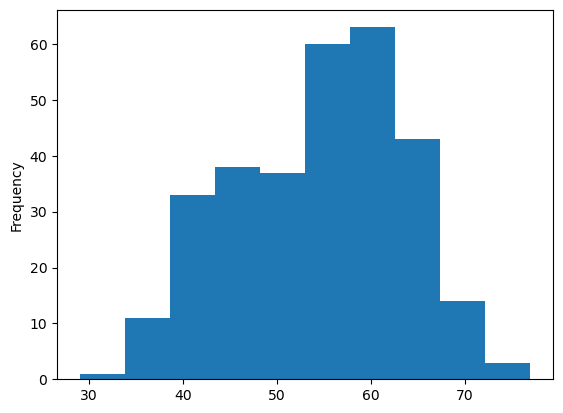

In [20]:
# distribution of the age column with a histogram
df.age.plot.hist();

In [22]:
disease_by_cp=pd.crosstab(df.cp,df.target)

(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

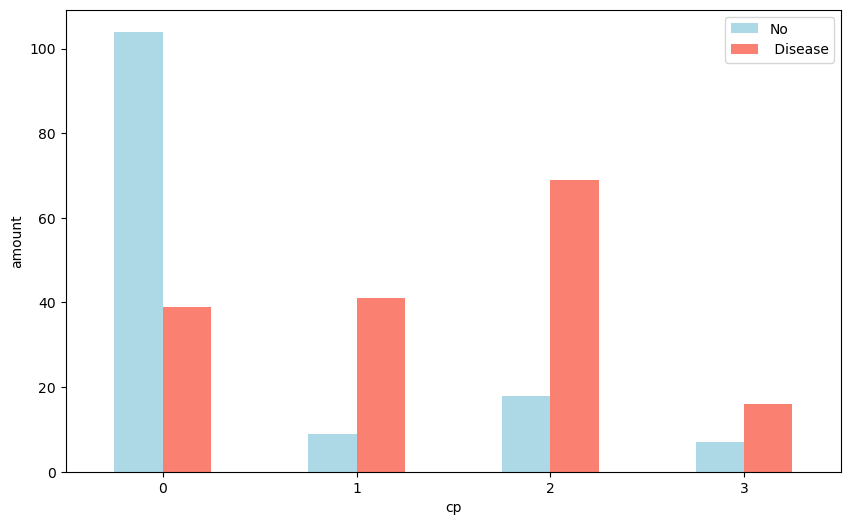

In [31]:
disease_by_cp.plot(kind='bar', figsize=(10,6), color=["lightblue", "salmon"])
plt.xlabel("cp")
plt.ylabel("amount")
plt.legend(["No"," Disease"])
plt.xticks(rotation=0)

In [ ]:
# make a corr matrix 
correlation_matrix=df.corr()


In [33]:
correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


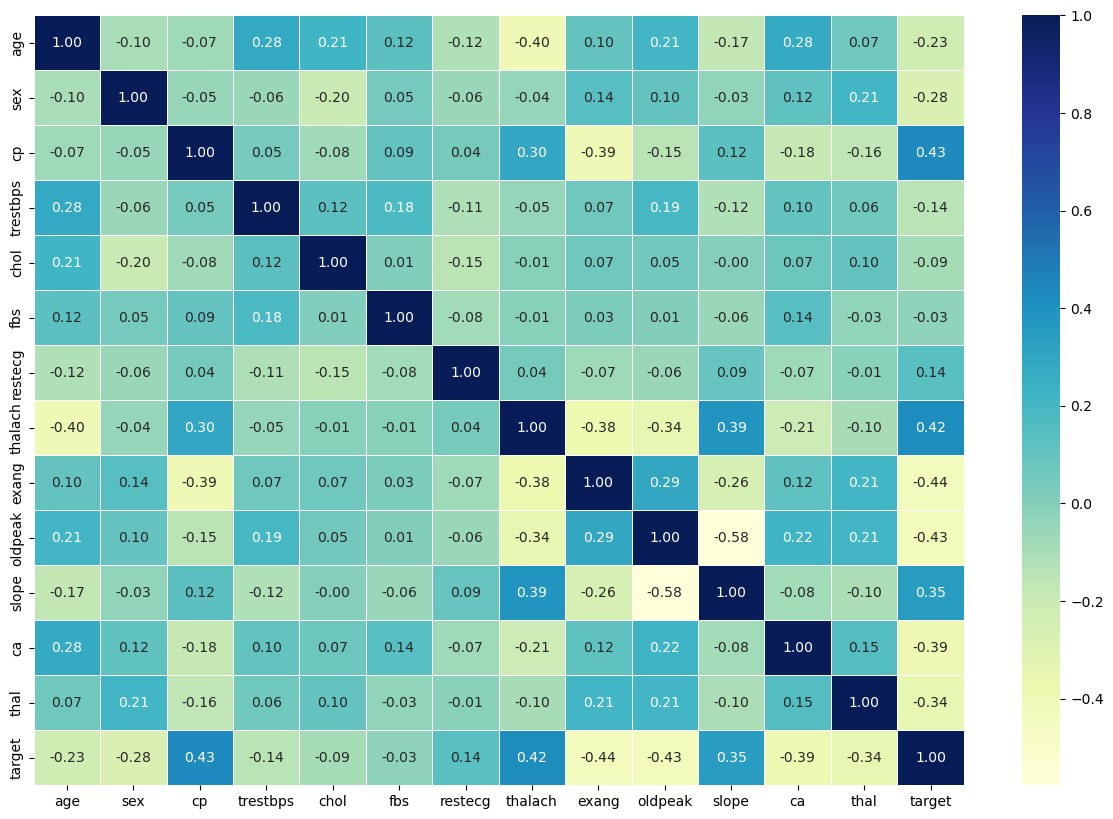

In [39]:
fig , ax=plt.subplots(figsize=(15,10))

ax=sns.heatmap(correlation_matrix,
               annot=True,
               linewidths=0.5,
               fmt=".2f",
                cmap="YlGnBu")

## modelling 


In [40]:
#split data into x and y

x=df.drop("target",axis=1)

y=df["target"]

In [41]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [42]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [43]:
np.random.seed(42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)



### time to build the model

### we gona to try 3 diff models 

### 1- logistc reg
### 2- KNN
### 3- RF


In [47]:
# put all in dictionary 
models= {"Logistic":LogisticRegression(),
         "RF":RandomForestClassifier(),
         "KNN":KNeighborsClassifier()}

In [48]:
#create a function to fit and score the models

def fit_and_score(models,x_train,x_test,y_train,y_test):
    np.random.seed(42)
    #make a dic to keep scores

    models_scores={}

    # loop through the model

    for name ,model in models.items():
        # fit the data 
        model.fit(x_train,y_train)

        # evaluate each model and append the score 
        models_scores[name]=model.score(x_test,y_test)
        
    return models_scores


In [50]:
model_scores=fit_and_score(models=models,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)

c:\Users\ii\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
model_scores

{'Logistic': 0.8852459016393442,
 'RF': 0.8360655737704918,
 'KNN': 0.6885245901639344}